# 1. feladat
Importáljuk a megfelelő modulokat az adatelemzéshez és vizualizációhoz. Az adatokat töltsük be a data.csv fájlból egy dataframe-be és ellenőrizzük a művelet eredményét. 2 pont

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv')

df.head()

,Geographical Location (Latitude),Geographical Location (Longitude),State of Sewage System,Sampling Date,Nitrogen (mg/L),Phosphorus (mg/L),Population
0,42.867278,-107.997678,Moderate,2015-09-30,5.447159,4.634808,923253
1,34.337029,-104.681197,Good,2020-01-29,9.087964,3.129082,1196631
2,34.831615,-93.134004,Moderate,2017-09-09,0.485658,4.545678,781628
3,45.463162,-120.709056,Poor,2019-11-12,2.666448,4.090627,855275
4,41.444474,-99.464055,Moderate,2016-08-19,8.425540,1.247981,1019428


# 2. feladat
Adatok áttekintése: Vizsgáljuk meg az adatkészletet, hogy megértsük annak szerkezetét és az adattípusokat. Jelenítsük meg ezt az információt a dataframe-ről. 0,5 pont

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Geographical Location (Latitude)   412 non-null    float64
 1   Geographical Location (Longitude)  412 non-null    float64
 2   State of Sewage System             412 non-null    object 
 3   Sampling Date                      412 non-null    object 
 4   Nitrogen (mg/L)                    412 non-null    float64
 5   Phosphorus (mg/L)                  412 non-null    float64
 6   Population                         412 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 22.7+ KB


# 3. feladat
Adatok előfeldolgozása: Végezzünk adatelőkészítést az elemzés előtt. Alakítsuk át a mintavételi dátumot ('Sampling Date') dátum-idő formátumra, és ellenőrizzük, hogy vannak-e hiányozó értékek a dataframe-ben. 1,5 pont

In [29]:
df['Sampling Date'] = pd.to_datetime(df['Sampling Date'], errors='coerce')

df.isnull().sum()


Geographical Location (Latitude)     0
Geographical Location (Longitude)    0
State of Sewage System               0
Sampling Date                        0
Nitrogen (mg/L)                      0
Phosphorus (mg/L)                    0
Population                           0
dtype: int64

# 4. feladat: 
Feltáró adatelemzés: Nézzük meg az adatokat néhány vizualizációval, hogy megértsük a szennyezőanyagok szintjeinek eloszlását és a szennyvízrendszerek állapotát a különböző földrajzi helyeken.

# 4.a
Ábrázoljuk a nitrogén és foszfor szintek eloszlását Matplotlib histogram-mal két subplot elhelyezésével egy közös ábrán. Az ábra méretét célszerű 12x6-ra beállítani.
A diagramokat lássuk el jelmagyarázattal, diagramcímmel és tengelyfeliratokkal. A diagramokban a KDE is kerüljön ábrázolásra. 2,5 pont

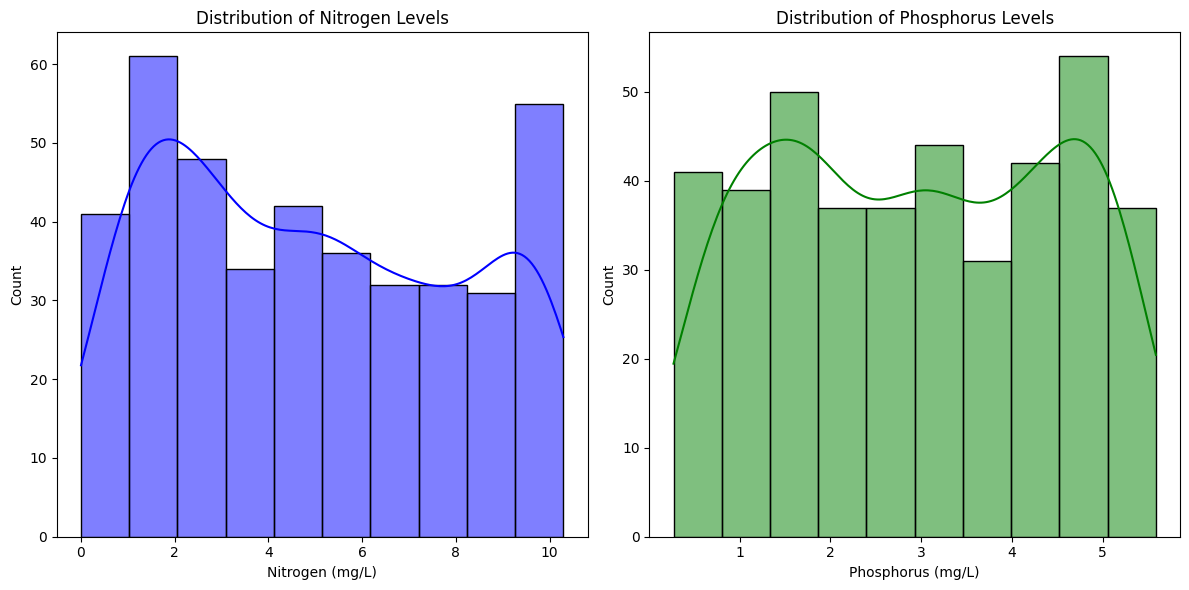

In [30]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Nitrogen (mg/L)'], kde=True, color='blue', bins=10)
plt.title('Distribution of Nitrogen Levels')
plt.xlabel('Nitrogen (mg/L)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df['Phosphorus (mg/L)'], kde=True, color='green', bins=10)
plt.title('Distribution of Phosphorus Levels')
plt.xlabel('Phosphorus (mg/L)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# 4.b
Ábrázoljuk a nitrogén szintek geográfiai eloszlását scatter-en, ahol a vízszintes tengelyen a Longitude és a függőleges tengelyen a Latitude értékek szerepeljenek. A hue paramétert a 'Nitrogen (mg/L)' értékekre állítsuk be, és használjunk 'coolwarm' színpalettát. 2 pont

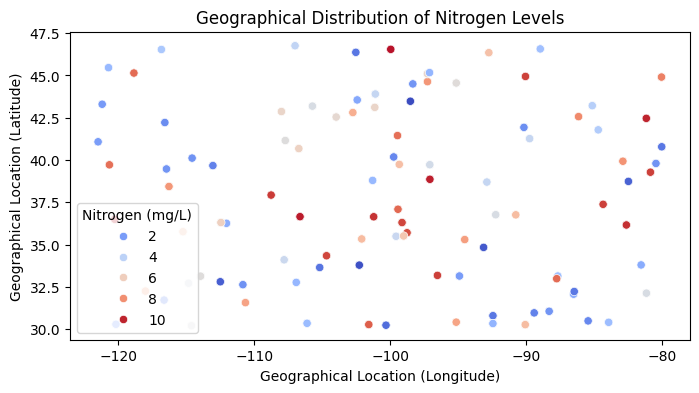

In [31]:
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=df,
    x='Geographical Location (Longitude)',
    y='Geographical Location (Latitude)',
    hue='Nitrogen (mg/L)',
    palette='coolwarm',
)
plt.title('Geographical Distribution of Nitrogen Levels')

plt.show()

# 4.c
Ábrázoljuk a foszfor szintek geográfiai eloszlását scatter-en, ahol a vízszintes tengelyen a Longitude és a függőleges tengelyen a Latitude értékek szerepeljenek. A hue paramétert a 'Phosphorus (mg/L)' értékekre állítsuk be, és használjunk itt is 'coolwarm' színpalettát. 1 pont

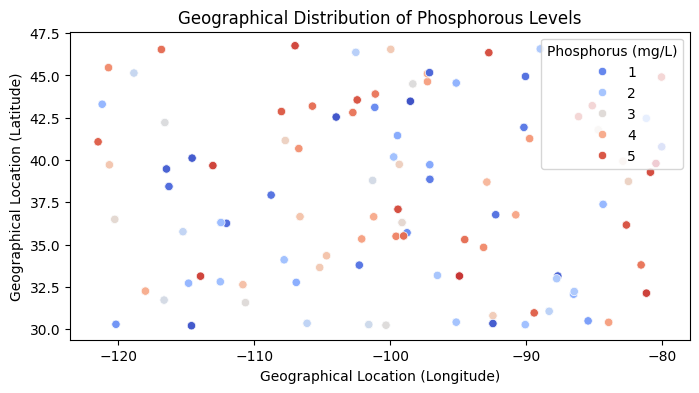

In [32]:
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=df,
    x='Geographical Location (Longitude)',
    y='Geographical Location (Latitude)',
    hue='Phosphorus (mg/L)',
    palette='coolwarm',
)
plt.title('Geographical Distribution of Phosphorous Levels')

plt.show()

# 5. feladat
Ábrázoljuk a nitrogén szinteket valós térképen: Hozzuk létre a map objektumot és jelenítsük meg az interaktív térképet az adott GPS koordinátákkal együtt. 3 pont

In [35]:
from matplotlib import colors
import folium

max_N = round(df['Nitrogen (mg/L)'].max())
print(max_N)
levels = range(max_N+1)
color_dict = dict(zip(levels, list(colors.cnames.values())[0:-1:10]))
color_dict

map_center = [df['Geographical Location (Latitude)'].mean(), df['Geographical Location (Longitude)'].mean()]
m = folium.Map(location=map_center, zoom_start=4, tiles='OpenStreetMap')

for ind, row in df.iterrows():
    N_level = int(round(row['Nitrogen (mg/L)']))
    folium.CircleMarker(
        location=[row['Geographical Location (Latitude)'], row['Geographical Location (Longitude)']],
        color=color_dict.get(N_level), 
        fill=True,
    ).add_to(m)

m


10


# 6. feladat
A szennyvízrendszer állapota: Készítsünk gyakoriság diagramot a State of Sewage System lehetséges állapotairól. Használjuk a Seaborn histplot metódusát és a kép méretét 6x6-osra állítsuk be. A diagramot lássuk el jelmagyarázattal, diagramcímmel és tengelyfeliratokkal. 2,5 pont

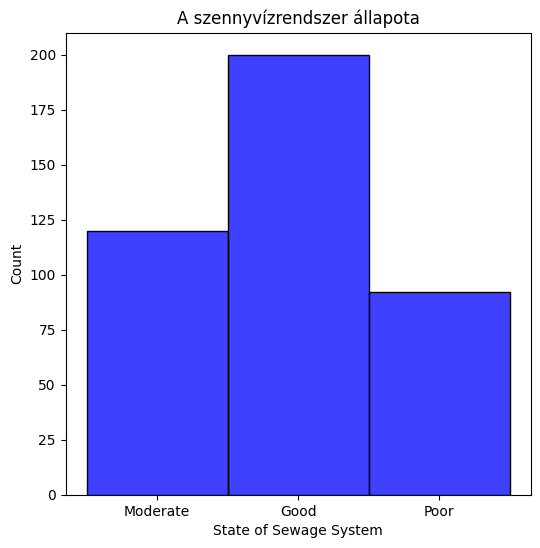

In [36]:
plt.figure(figsize=(6,6))

sns.histplot(
    data=df,
    x='State of Sewage System',
    color='blue'
)

plt.title('A szennyvízrendszer állapota')
plt.xlabel('State of Sewage System')
plt.ylabel('Count')

plt.show()


# 7. feladat: Korrelációs elemzés

## 7.a
Vizsgáljuk meg az adatkészlet numerikus változói közötti korrelációt, hogy azonosítani tudjuk az esetleges kapcsolatokat. Először hozzuk létre az N+P oszlopot, ahol a teljes mért szennyezés értékét (a nitrogén és foszfor mennyiségek összegét) jelenítjük meg a mérési helyeken, a mért időpontokban. 1 pont

In [37]:
df['N+P'] = df['Nitrogen (mg/L)'] + df['Phosphorus (mg/L)']
df[['Geographical Location (Latitude)', 'Geographical Location (Longitude)', 'Sampling Date', 'N+P']].head()

,Geographical Location (Latitude),Geographical Location (Longitude),Sampling Date,N+P
0,42.867278,-107.997678,2015-09-30,10.081967
1,34.337029,-104.681197,2020-01-29,12.217047
2,34.831615,-93.134004,2017-09-09,5.031337
3,45.463162,-120.709056,2019-11-12,6.757075
4,41.444474,-99.464055,2016-08-19,9.673521


## 7.b
A szennyvízrendszer állapotát megadó State of Sewage System oszlop adatait konvertáljuk számértértékké a LabelEncoder alkalmazásával. Ellenőrizzük az eredményt. 2 pont

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['State of Sewage System'] = le.fit_transform(df['State of Sewage System'])

df['State of Sewage System'].head()

0    1
1    0
2    1
3    2
4    1
Name: State of Sewage System, dtype: int64

## 7.c
Válogassuk ki a csak numerikus adatokat tartalmazó oszlopokat egy új dataframe-be, végezzük el a korreláció vizsgálatát a pearson módszer alkalmazásával, és jelenítsük meg a korrelációs mátrixot. 3 pont

In [42]:
numerical_df = df.select_dtypes(include='number')

corr_matrix = numerical_df.corr(method='pearson')

corr_matrix

,Geographical Location (Latitude),Geographical Location (Longitude),State of Sewage System,Nitrogen (mg/L),Phosphorus (mg/L),Population,N+P
Geographical Location (Latitude),1.000000,-0.026431,0.159436,0.098404,0.136975,0.125905,0.144005
Geographical Location (Longitude),-0.026431,1.000000,-0.005862,0.038998,0.111169,0.074368,0.081572
State of Sewage System,0.159436,-0.005862,1.000000,-0.048953,0.107719,-0.028886,0.004110
Nitrogen (mg/L),0.098404,0.038998,-0.048953,1.000000,0.091690,0.880114,0.903346
Phosphorus (mg/L),0.136975,0.111169,0.107719,0.091690,1.000000,0.474702,0.509933
Population,0.125905,0.074368,-0.028886,0.880114,0.474702,1.000000,0.964755
N+P,0.144005,0.081572,0.004110,0.903346,0.509933,0.964755,1.000000


## 7.d
A korreláció vizualizációhoz használjunk heatmap diagramot, a korrelációs együtthatók megjelenítésével (2 tizedesjegyre kerekítve), coolwarm színtérképpel, 8x6-os képmérettel és diagramcímmel. 2,5 pont

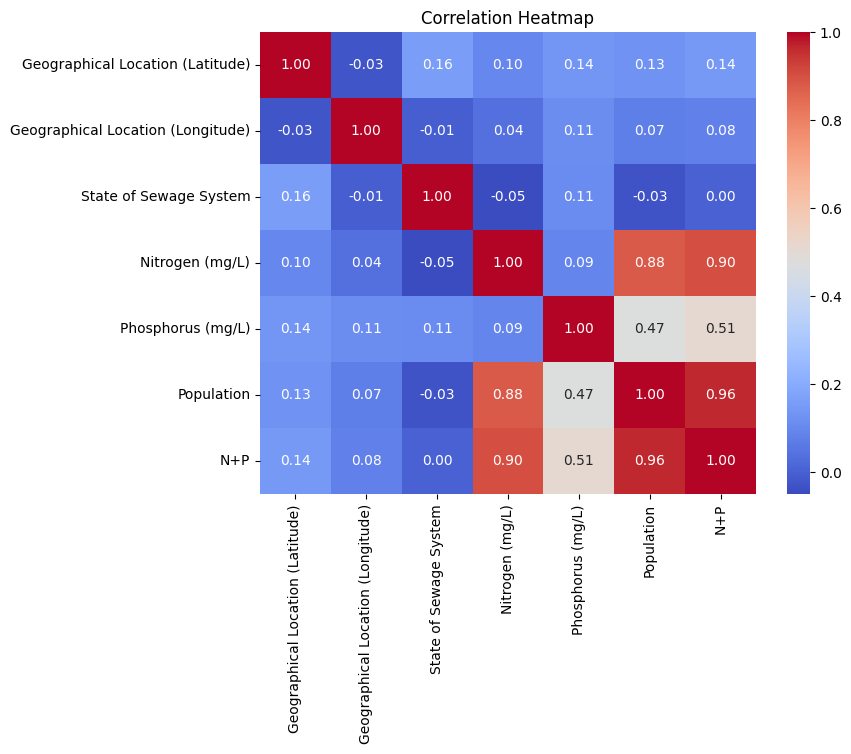

In [43]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
)

plt.title('Correlation Heatmap')
plt.show()

# 8. feladat
Rövidítsük a mezőneveket a következőképpen:
Lati = Geographical Location (Latitude)
Long = Geographical Location (Longitude)
SDate = Sampling Date
N = Nitrogen (mg/L)
P = Phosphorus (mg/L)
SWS = State of Sewage System
Ellenőrizzük az info() metódussal, hogy sikeres volt-e az átnevezés. 1,5 pont

In [44]:
df = df.rename(columns={
    'Geographical Location (Latitude)': 'Lati',
    'Geographical Location (Longitude)': 'Long',
    'Sampling Date': 'SDate',
    'Nitrogen (mg/L)': 'N',
    'Phosphorus (mg/L)': 'P',
    'State of Sewage System': 'SWS'
})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Lati        412 non-null    float64       
 1   Long        412 non-null    float64       
 2   SWS         412 non-null    int64         
 3   SDate       412 non-null    datetime64[ns]
 4   N           412 non-null    float64       
 5   P           412 non-null    float64       
 6   Population  412 non-null    int64         
 7   N+P         412 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 25.9 KB


# 9. feladat
Készítsük el az adatok statisztikai jellemzését: Használjuk a describe() utasítást. 1 pont

In [45]:
df.describe()

,Lati,Long,SWS,SDate,N,P,Population,N+P
count,412.000000,412.000000,412.000000,412,412.000000,412.000000,4.120000e+02,412.000000
mean,37.928978,-99.910523,0.737864,2019-02-16 10:08:09.320388352,4.956458,2.941068,9.041799e+05,7.897526
min,30.198108,-121.476341,0.000000,2014-01-02 00:00:00,0.004284,0.272931,2.053480e+05,0.379070
25%,33.138387,-107.997678,0.000000,2016-12-24 18:00:00,2.096088,1.593510,6.752212e+05,4.725642
50%,37.926803,-99.464055,1.000000,2018-12-08 12:00:00,4.821583,2.951642,8.774995e+05,7.935702
75%,42.542049,-90.071769,1.000000,2021-07-02 06:00:00,7.575510,4.327313,1.184369e+06,10.852442
max,46.759853,-80.039258,2.000000,2023-12-25 00:00:00,10.294660,5.586694,1.544160e+06,15.538928
std,5.088459,11.689830,0.800987,NaN,3.097449,1.544422,3.163950e+05,3.585622


# 10. feladat
Vizsgáljuk meg azokat a helyeket, ahol a N+P koncentráció magas. Ehhez készítsünk egy Q (quality) oszlopot az apply függvény alkalmazásával, a következő értékekkel: 1, ha N+P 4-nél kisebb; 3, ha 10-nél nagyobb; a közbeeső tartományra az érték legyen 2. Ellenőrizzük az eredményt. 2,5 pont

In [46]:
def q(np):
    if np < 4:
        return 1
    elif np > 10:
        return 3
    else:
        return 2

df['Q'] = df['N+P'].apply(q)
df[['N+P', 'Q']].head(15)

,N+P,Q
0,10.081967,3
1,12.217047,3
2,5.031337,2
3,6.757075,2
4,9.673521,2
5,15.419639,3
6,12.502459,3
7,8.660673,2
8,3.189861,1
9,13.641780,3


# 11. feladat
Csoportosítsuk a Q oszlop értékeit és írassuk ki a csoportok méretét. 1,5 pont

In [47]:
df.groupby('Q').size()

Q
1     77
2    193
3    142
dtype: int64

# 12. feladat
Jelenítsük meg a Q értékek geográfiai eloszlását Seaborn scatterplot-tal, coolwarm színpalettával. A kép méretét 10x6-osra és a hue paramétert a Q értékekre állítsuk be. A diagramot lássuk el jelmagyarázattal, diagramcímmel és tengelyfeliratokkal. 1 pont

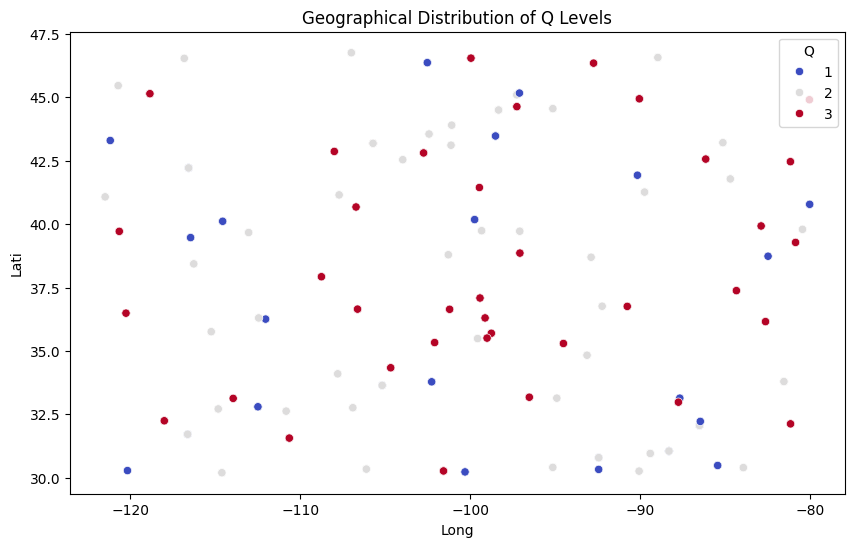

In [48]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Long',
    y='Lati',
    hue='Q',
    palette='coolwarm',
)
plt.title('Geographical Distribution of Q Levels')

plt.show()

# 13. feladat
A következő részben készítsünk egy elemzést a DecisionTree modellel, a kapott modell értékelésével, és a döntési fa megjelenítésével. Importáljuk a szükséges modulokat és osztályokat a Scikit-learn könyvtárból.
Ebben az elemzésben nem használjuk a dátum adatokat, ezért a vizsgálathoz hozzunk létre egy új dataframe-et az SDate oszlop nélkül. Ellenőrizzük az új dataframe-et.
A modell alkalmazásához erre az új dataframe-re válasszuk szét az adathalmazt független (`x`) és függő (`y`) változókra, az y értékeknek az SWS oszlopot választva. 4,5 pont

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df2 = df.drop(columns=['SDate'])
df2.info()

x=df2.drop(columns=['SWS'])
y=df2['SWS']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Lati        412 non-null    float64
 1   Long        412 non-null    float64
 2   SWS         412 non-null    int64  
 3   N           412 non-null    float64
 4   P           412 non-null    float64
 5   Population  412 non-null    int64  
 6   N+P         412 non-null    float64
 7   Q           412 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.9 KB


# 14. feladat
Adatok felosztása, modellépítés és betanítás. Vizualizáció
Osszuk fel az adatokat 4:1 arányban véletlenszerűen train és test adatokra, és tanítsuk be a modellünket. Vizualizáljuk a döntési fát a Matplotlib segítségével, az ábra méretét célszerű 12x8-ra beállítani. 4 pont

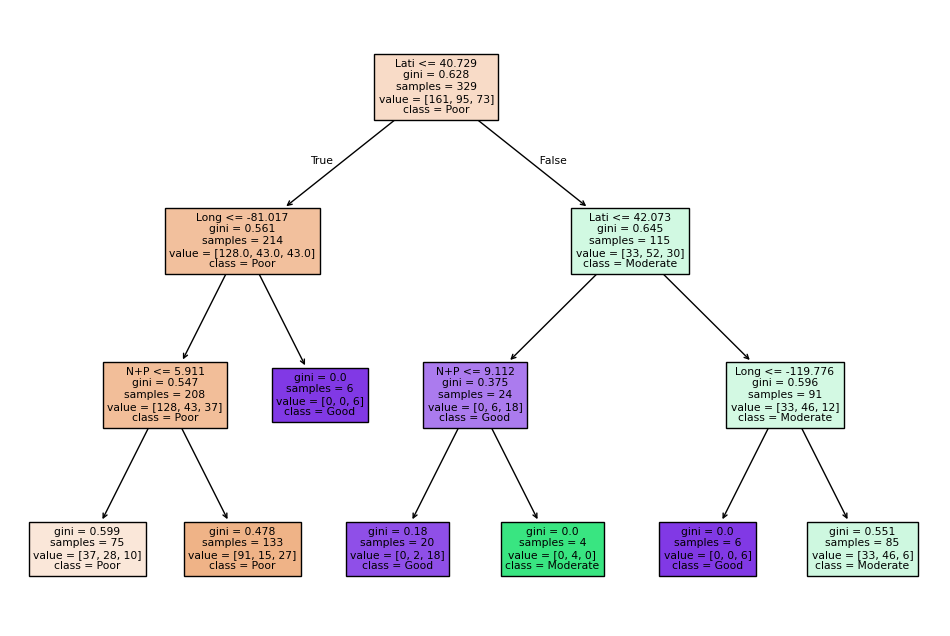

In [55]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, test_size=0.2)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(x_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=x.columns, class_names=['Poor', 'Moderate', 'Good'])
plt.show()

# 15.feladat: A modell értékelése
Készítsünk predikciót a teszt halmazon. Számítsuk ki a pontosságot. Generáljunk osztályozási riportot és konfúziós mátrixot és ezeket jelenítsük meg. 4 pont

In [56]:

y_pred = model.predict(x_test)

accuracy_score(y_test, y_pred)

display(classification_report(y_test, y_pred))
display(confusion_matrix(y_test, y_pred))

'              precision    recall  f1-score   support\n\n           0       0.57      0.82      0.67        39\n           1       0.53      0.40      0.45        25\n           2       0.75      0.32      0.44        19\n\n    accuracy                           0.58        83\n   macro avg       0.62      0.51      0.52        83\nweighted avg       0.60      0.58      0.56        83\n'

array([[32,  7,  0],
       [13, 10,  2],
       [11,  2,  6]])

# 16. feladat
A népesség és a szennyezettség mértékének kapcsolatának vizsgálata Lineáris Regresszióval
A következő részben készítsünk egy elemzést a LinearRegression modellel, a kapott modell értékelésével, és a scatter diagram megjelenítésével. Először importáljuk a szükséges modulokat és osztályokat a Scikit-learn könyvtárból. Független változónak a Population oszlopot, és függő változónak az N+P oszlopot válasszuk.
Osszuk fel az adatokat 4:1 arányban véletlenszerűen train és test adatokra, és tanítsuk be a modellünket. Vizualizáljuk a teszt adatokat és a lineáris regressziót is jelenítésük meg a Matplotlib scatter alkalmazásával. 8,5 pont

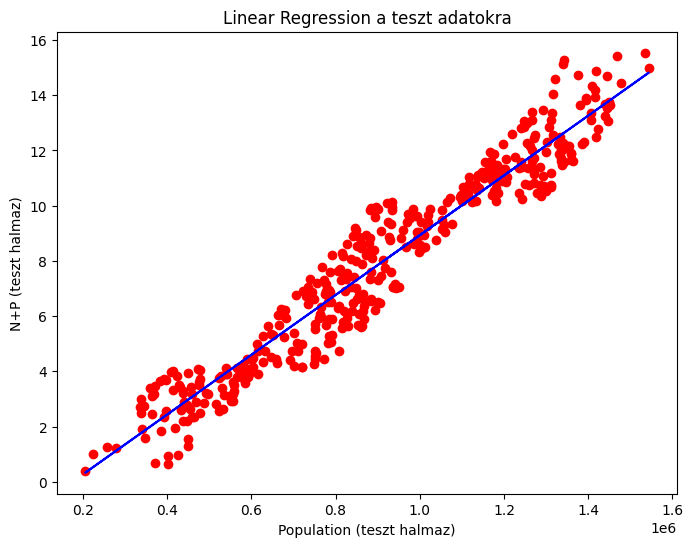

In [57]:
from sklearn.linear_model import LinearRegression

x = df[['Population']]
y = df['N+P']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, test_size=0.2)

lr = LinearRegression()
lr.fit(x_train, y_train)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='red')
plt.plot(x, lr.predict(x), color='blue')
plt.xlabel('Population (teszt halmaz)')
plt.ylabel('N+P (teszt halmaz)')
plt.title('Linear Regression a teszt adatokra')
plt.show()

# 17. feladat
A modell értékelése
Készítsünk predikciót a teszt halmazon, és jelenítsük meg az első öt predikció, és az első öt valós y teszt értékeket. Írassuk ki a betanított modellünk pontosságát is. 4 pont

In [58]:
y_pred = lr.predict(x_test)

display(y_pred[:5])
display(y_test.values[:5])

display(lr.score(x_test, y_test))

array([ 3.76129086, 12.59454963, 10.77507314,  6.90387537,  8.32664677])

array([ 3.74986051, 11.45888569, 10.40143405,  7.30029527,  7.01582539])

0.9303481081343687